
# Tutorial 9 — **Optimización de modelos**, **Validación cruzada** y **Exportación**

**Objetivo**: Aprender a **buscar hiperparámetros** (Grid/Randomized Search), **comparar métricas** entre configuraciones, aplicar **validación cruzada** y **exportar** modelos ya entrenados.




<a id="material"></a>
## 1) Material de estudio



<a id="param-hparam"></a>
### 1.1 Parámetros vs hiperparámetros

- **Parámetros**: los aprende el modelo durante `fit(...)` (p.ej., coeficientes en una regresión).  
- **Hiperparámetros**: configuran el comportamiento del algoritmo **antes** del entrenamiento (p.ej., `n_neighbors` en KNN, `C` en SVM, profundidad de un árbol).  
Elegirlos bien impacta directamente en el desempeño y en la **capacidad de generalización**.



<a id="search"></a>
### 1.2 Búsqueda de hiperparámetros

- **`GridSearchCV`**: prueba todas las combinaciones de una grilla definida (exhaustivo).  
- **`RandomizedSearchCV`**: prueba un número aleatorio de combinaciones (más eficiente en espacios grandes).  
Ambos integran **validación cruzada** internamente y devuelven la **mejor combinación** y el **mejor estimador**.



<a id="cv"></a>
### 1.3 Validación cruzada y métricas

- **Validación cruzada (CV)**: divide los datos en *k* pliegues y promedia el desempeño → evaluación más **estable** y **robusta**.  
- **Regresión**: `R²` (↑ mejor), `MAE` y `RMSE` (↓ mejor).  
- **Clasificación**: `accuracy`, `precision`, `recall`, `f1`, `ROC-AUC`.  
> Tip: Usa `cross_validate(..., scoring={...}, return_train_score=True)` para comparar varias métricas a la vez.



<a id="export"></a>
### 1.4 Exportación y carga de modelos

Tras validar y ajustar hiperparámetros, **guarda** tu modelo (o **pipeline**) con `joblib.dump(...)` y recupéralo con `joblib.load(...)`.  
Así evitas reentrenar y puedes **reutilizar** el flujo (preprocesamiento + modelo) con datos nuevos.



<a id="ejemplos"></a>
## 2) Ejemplos



<a id="reg"></a>
### 2.1 Regresión — comparación de modelos + *tuning*

**Dataset**: `diabetes` (incluido en scikit‑learn).  
**Modelos base**: `LinearRegression`, `Ridge`, `RandomForestRegressor`, `SVR`.  
**Búsqueda**: usaremos `GridSearchCV` para `Ridge` y `SVR`; `RandomizedSearchCV` para `RandomForestRegressor`.  
**Métricas**: `R²`, `MAE`, `RMSE`. **Selección** por mejor `R²` en *test*.


In [1]:
# --- REGRESIÓN: comparación + búsqueda de hiperparámetros ----------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("Cargando dataset de diabetes (regresión)")


data = load_diabetes()
X, y = data.data, data.target

Cargando dataset de diabetes (regresión)


In [2]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

# Pipelines base
pipe_lr   = Pipeline([("scaler", StandardScaler()), ("model", LinearRegression())])
pipe_ridge= Pipeline([("scaler", StandardScaler()), ("model", Ridge())])
rf        = RandomForestRegressor(random_state=42)
pipe_svr  = Pipeline([("scaler", StandardScaler()), ("model", SVR())])

modelos = {
    "LinearRegression": pipe_lr,
    "Ridge": pipe_ridge,
    "RandomForest": rf,
    "SVR": pipe_svr
}

print("\nEvaluando modelos base con cross_validate (cv=5)")




Evaluando modelos base con cross_validate (cv=5)


In [3]:
scoring = {"r2": "r2", "mae": "neg_mean_absolute_error", "rmse": "neg_root_mean_squared_error"}
filas = []
for nombre, est in modelos.items():
    cvres = cross_validate(est, X_tr, y_tr, cv=5, scoring=scoring, n_jobs=None, return_train_score=False)
    filas.append([nombre,
                  cvres["test_r2"].mean(),
                  -cvres["test_mae"].mean(),
                  -cvres["test_rmse"].mean()])
df_base = pd.DataFrame(filas, columns=["modelo","cv_r2","cv_mae","cv_rmse"]).sort_values("cv_r2", ascending=False)
print(df_base)

             modelo     cv_r2     cv_mae    cv_rmse
1             Ridge  0.451266  45.482945  55.916494
0  LinearRegression  0.449256  45.543329  55.972086
2      RandomForest  0.390932  48.089894  59.065156
3               SVR  0.111532  60.653242  72.554903


In [4]:

# --- Grid / Randomized Search sobre algunos modelos ---
print("\nBuscando hiperparámetros...")

# Ridge (grid)
grid_ridge = {"model__alpha": [0.1, 0.5, 1.0, 2.0, 5.0, 10.0]}
gs_ridge = GridSearchCV(pipe_ridge, grid_ridge, cv=5, scoring="r2")
gs_ridge.fit(X_tr, y_tr)

# SVR (grid pequeño)
grid_svr = {"model__C": [0.5, 1, 5, 10], "model__gamma": ["scale", 0.1, 0.01], "model__epsilon": [0.1, 0.2]}
gs_svr = GridSearchCV(pipe_svr, grid_svr, cv=5, scoring="r2")
gs_svr.fit(X_tr, y_tr)

# RandomForest (randomized)
dist_rf = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [None, 4, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
rs_rf = RandomizedSearchCV(rf, dist_rf, n_iter=15, cv=5, scoring="r2", random_state=42)
rs_rf.fit(X_tr, y_tr)


candidatos = {
    "Ridge*": gs_ridge.best_estimator_,
    "SVR*": gs_svr.best_estimator_,
    "RandomForest*": rs_rf.best_estimator_,
    "LinearRegression (sin tuning)": pipe_lr
}

print("\nMejores parámetros:")
print(" - Ridge:", gs_ridge.best_params_)
print(" - SVR:", gs_svr.best_params_)
print(" - RandomForest:", rs_rf.best_params_)



Buscando hiperparámetros...

Mejores parámetros:
 - Ridge: {'model__alpha': 10.0}
 - SVR: {'model__C': 10, 'model__epsilon': 0.2, 'model__gamma': 'scale'}
 - RandomForest: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 4}


In [5]:

# Evaluación final en test
res_final = []
for nombre, est in candidatos.items():
    est.fit(X_tr, y_tr)
    pred = est.predict(X_te)
    r2 = r2_score(y_te, pred)
    mae = mean_absolute_error(y_te, pred)
    rmse = np.sqrt(mean_squared_error(y_te, pred))
    res_final.append([nombre, r2, mae, rmse])
df_final = pd.DataFrame(res_final, columns=["modelo","R2_test","MAE_test","RMSE_test"]).sort_values("R2_test", ascending=False)
print("\nRendimiento final en TEST (ordenado por R2):")
print(df_final)


Rendimiento final en TEST (ordenado por R2):
                          modelo   R2_test   MAE_test  RMSE_test
1                           SVR*  0.493855  41.310746  51.784488
2                  RandomForest*  0.468780  43.188321  53.051725
0                         Ridge*  0.457211  42.856825  53.626288
3  LinearRegression (sin tuning)  0.452603  42.794095  53.853446


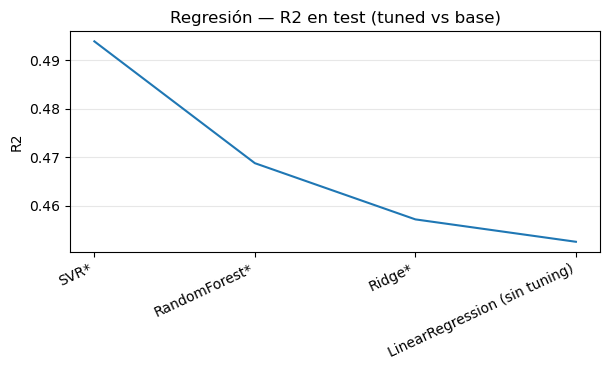

In [6]:
# Visualizaciones (una figura por gráfico)
plt.figure(figsize=(6.2, 3.8))
plt.plot(df_final["modelo"], df_final["R2_test"])
plt.title("Regresión — R2 en test (tuned vs base)")
plt.ylabel("R2")
plt.xticks(rotation=25, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

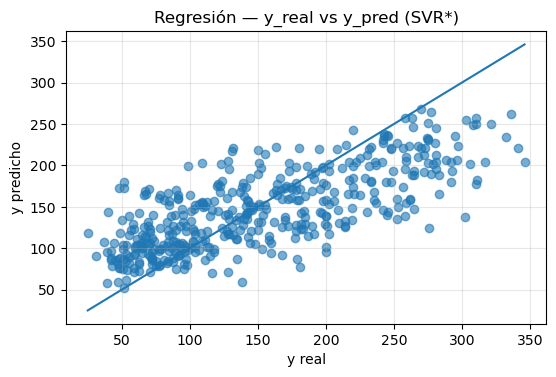

In [7]:
# Dispersión y_real vs y_pred del mejor
best_name = df_final.iloc[0]["modelo"]
best_est  = candidatos[best_name]
y_pred_best = best_est.predict(X_te)

plt.figure(figsize=(6.2, 3.8))
plt.scatter(y, best_est.predict(X), alpha=0.6)
mn, mx = np.min([y, best_est.predict(X)]), np.max([y, best_est.predict(X)])
plt.plot([mn, mx], [mn, mx])
plt.title(f"Regresión — y_real vs y_pred ({best_name})")
plt.xlabel("y real"); plt.ylabel("y predicho")
plt.grid(True, alpha=0.3)
plt.show()


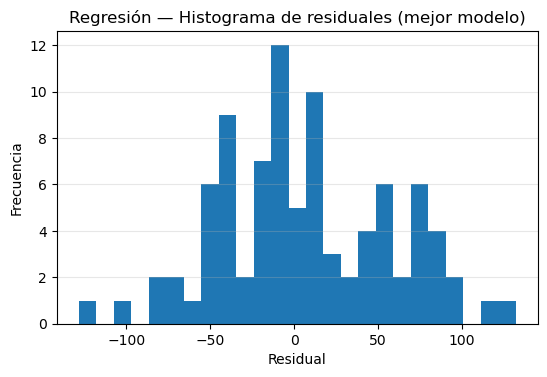

In [8]:
# Histograma de residuales del mejor
resid = y_te - y_pred_best
plt.figure(figsize=(6.2, 3.8))
plt.hist(resid, bins=25)
plt.title("Regresión — Histograma de residuales (mejor modelo)")
plt.xlabel("Residual"); plt.ylabel("Frecuencia")
plt.grid(axis="y", alpha=0.3)
plt.show()


<a id="clf"></a>
### 2.2 Clasificación — comparación de modelos + *tuning*

**Dataset**: `breast_cancer` (incluido en scikit‑learn).  
**Modelos base**: `LogisticRegression`, `RandomForestClassifier`, `SVC`.  
**Búsqueda**: `GridSearchCV` para `SVC` y `RandomizedSearchCV` para `RandomForestClassifier`.  
**Métricas**: `accuracy`, `precision`, `recall`, `f1`, `ROC-AUC`.


In [9]:

# --- CLASIFICACIÓN: comparación + búsqueda de hiperparámetros -----------

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix


In [10]:
print("Cargando dataset breast_cancer (clasificación)...")
bc = load_breast_cancer()
X, y = bc.data, bc.target
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y)

# Modelos base
pipe_logreg = Pipeline([("scaler", StandardScaler()), ("model", LogisticRegression(max_iter=2000))])
rf          = RandomForestClassifier(random_state=0)
pipe_svc    = Pipeline([("scaler", StandardScaler()), ("model", SVC(probability=True))])

modelos = {"LogReg": pipe_logreg, "RandomForest": rf, "SVC": pipe_svc}

print("\nEvaluando modelos base con cross_validate (cv=5)...")
scoring = {"acc": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "roc_auc": "roc_auc"}
filas = []
for nombre, est in modelos.items():
    cvres = cross_validate(est, X_tr, y_tr, cv=5, scoring=scoring, n_jobs=None, return_train_score=False)
    filas.append([nombre,
                  cvres["test_acc"].mean(),
                  cvres["test_precision"].mean(),
                  cvres["test_recall"].mean(),
                  cvres["test_f1"].mean(),
                  cvres["test_roc_auc"].mean()])
df_base = pd.DataFrame(filas, columns=["modelo","cv_acc","cv_precision","cv_recall","cv_f1","cv_roc_auc"]).sort_values("cv_f1", ascending=False)
print(df_base)

Cargando dataset breast_cancer (clasificación)...

Evaluando modelos base con cross_validate (cv=5)...
         modelo    cv_acc  cv_precision  cv_recall     cv_f1  cv_roc_auc
2           SVC  0.980220      0.986146   0.982456  0.984193    0.995562
0        LogReg  0.969231      0.968959   0.982456  0.975621    0.994427
1  RandomForest  0.967033      0.965572   0.982456  0.973912    0.995614


In [11]:

# --- Tuning ---
print("\nBuscando hiperparámetros...")

# SVC (grid pequeño)
grid_svc = {"model__C": [0.5, 1, 2, 5, 10],
            "model__gamma": ["scale", 0.1, 0.01],
            "model__kernel": ["rbf"]}
gs_svc = GridSearchCV(pipe_svc, grid_svc, cv=5, scoring="f1")
gs_svc.fit(X_tr, y_tr)

# RandomForest (randomized)
dist_rf = {
    "n_estimators": [100, 200, 400, 600],
    "max_depth": [None, 4, 6, 8, 10, 12],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}
rs_rf = RandomizedSearchCV(rf, dist_rf, n_iter=15, cv=5, scoring="f1", random_state=0)
rs_rf.fit(X_tr, y_tr)

candidatos = {
    "LogReg (base)": pipe_logreg,
    "SVC*": gs_svc.best_estimator_,
    "RandomForest*": rs_rf.best_estimator_
}

print("\nMejores parámetros:")
print(" - SVC:", gs_svc.best_params_)
print(" - RandomForest:", rs_rf.best_params_)



Buscando hiperparámetros...

Mejores parámetros:
 - SVC: {'model__C': 5, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
 - RandomForest: {'n_estimators': 600, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 12}


In [12]:
# Evaluación final en test
filas = []
probas = {}
for nombre, est in candidatos.items():
    est.fit(X_tr, y_tr)
    yp = est.predict(X_te)
    acc = accuracy_score(y_te, yp)
    pre = precision_score(y_te, yp)
    rec = recall_score(y_te, yp)
    f1  = f1_score(y_te, yp)
    if hasattr(est, "predict_proba"):
        pr = est.predict_proba(X_te)[:,1]
    else:
        # decision_function -> escalar a [0,1] si corresponde
        if hasattr(est, "decision_function"):
            from sklearn.preprocessing import MinMaxScaler
            s = est.decision_function(X_te).reshape(-1,1)
            pr = MinMaxScaler().fit_transform(s).ravel()
        else:
            pr = None
    roc = roc_auc_score(y_te, pr) if pr is not None else np.nan
    filas.append([nombre, acc, pre, rec, f1, roc])
    probas[nombre] = pr

df_final = pd.DataFrame(filas, columns=["modelo","acc","precision","recall","f1","roc_auc"]).sort_values("f1", ascending=False)
print("\nRendimiento final en TEST (ordenado por F1):")
print(df_final)



Rendimiento final en TEST (ordenado por F1):
          modelo       acc  precision    recall        f1   roc_auc
0  LogReg (base)  0.982456   0.972973  1.000000  0.986301  0.995701
1           SVC*  0.973684   0.972603  0.986111  0.979310  0.994378
2  RandomForest*  0.947368   0.971429  0.944444  0.957746  0.969081


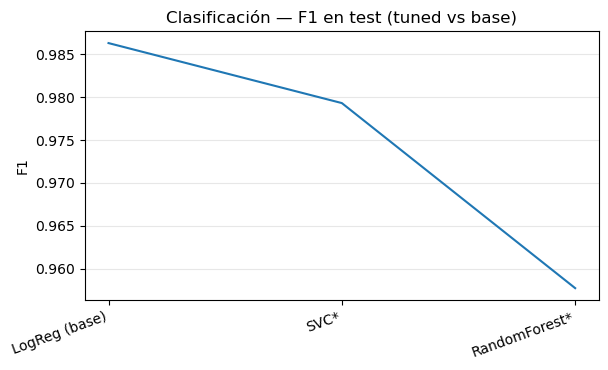

In [13]:

# Grafico F1
plt.figure(figsize=(6.2, 3.8))
plt.plot(df_final["modelo"], df_final["f1"])
plt.title("Clasificación — F1 en test (tuned vs base)")
plt.ylabel("F1")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


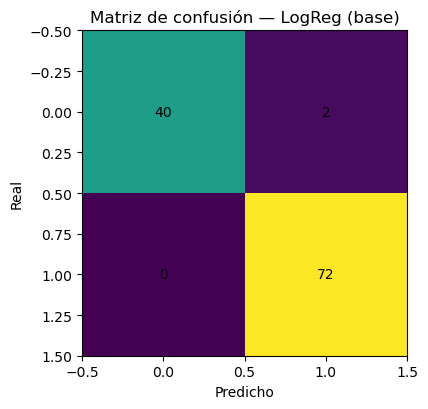

In [14]:

# Matriz de confusión del mejor
best_name = df_final.iloc[0]["modelo"]
best_model = candidatos[best_name]
yp_best = best_model.predict(X_te)
cm = confusion_matrix(y_te, yp_best)

plt.figure(figsize=(6.0, 4.2))
plt.imshow(cm)
plt.title(f"Matriz de confusión — {best_name}")
plt.xlabel("Predicho"); plt.ylabel("Real")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")
plt.tight_layout()
plt.show()


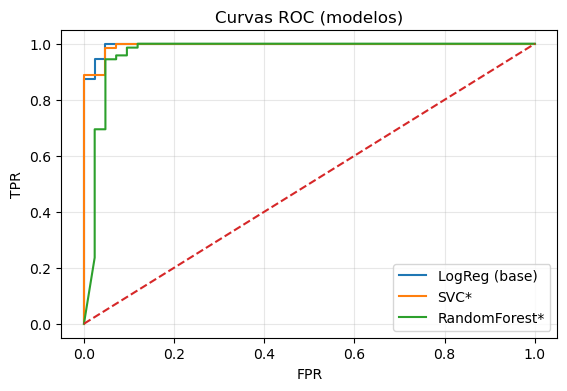

In [15]:

# Curvas ROC (si hay probabilidades)
plt.figure(figsize=(6.4, 4.0))
for nombre, pr in probas.items():
    if pr is None:
        continue
    fpr, tpr, _ = roc_curve(y_te, pr)
    plt.plot(fpr, tpr, label=nombre)
plt.plot([0,1], [0,1], linestyle="--")
plt.title("Curvas ROC (modelos)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


#### Exportación del mejor modelo (pipeline incluido)

Guardamos el **mejor estimador** de clasificación como ejemplo (también puedes guardar el de regresión).  
Luego lo cargamos y verificamos que predice correctamente con los datos de test.


In [16]:

from pathlib import Path
import joblib

# Tomamos el mejor de clasificación (ya entrenado arriba)
best_name = df_final.iloc[0]["modelo"]
best_model = candidatos[best_name]

out_path = Path("modelo_tutorial9_mejor.joblib")
joblib.dump(best_model, out_path)

['modelo_tutorial9_mejor.joblib']

In [17]:
# Cargar y probar
modelo_cargado = joblib.load(out_path)
yp_check = modelo_cargado.predict(X_te[:5])
print("Predicción de ejemplo con modelo cargado:", yp_check)

Predicción de ejemplo con modelo cargado: [0 0 0 1 0]



<a id="exercises"></a>
## 3) Ejercicios

> **Formato**: usa `print(...)` **descriptivos** y gráficos con títulos/ejes/leyendas.


### Ejercicio 1 — Comparativa ampliada (Regresión)
1. Agrega `Lasso` y ajusta una grilla de `alpha`.  
2. Compara `R²`, `MAE`, `RMSE` vs los modelos ya evaluados.  
3. Dibuja barras de `R²_test` por modelo y un histograma de residuales del mejor.


### Ejercicio 2 — Búsqueda avanzada (Clasificación)
1. Usa `GridSearchCV` para `SVC` y `RandomizedSearchCV` para `RandomForest` con espacios más amplios (pero razonables).  
2. Reporta `accuracy`, `precision`, `recall`, `f1`, `ROC-AUC`.  
3. Grafica ROC y **Precision‑Recall** del mejor.




### Ejercicio 3 — Validación cruzada estratificada y *nested CV*
1. Repite la comparación con `StratifiedKFold(cv=5, shuffle=True, random_state=...)`.  



### Ejercicio 4 — Exportación y prueba 
1. Exporta el **pipeline** mejor evaluado como `.joblib`.  
2. Ejecutalo y pruebalo
